# Elliptic Curve Cryptography

[Official documentation](https://qualtran.readthedocs.io/en/latest/bloqs/cryptography/ecc/ecc.html)

In [1]:
from qualtran import Bloq, CompositeBloq, BloqBuilder, Signature, Register
from qualtran import QBit, QInt, QUInt, QAny
from qualtran.drawing import show_bloq, show_call_graph, show_counts_sigma
from typing import *
import numpy as np
import sympy
import cirq

### FindECCPrivateKey

In [2]:
from qualtran.bloqs.cryptography.ecc import FindECCPrivateKey, ECPoint

n, p = sympy.symbols("n p")
Px, Py, Qx, Qy = sympy.symbols("P_x P_y Q_x Q_y")
P = ECPoint(Px, Py, mod=p)
Q = ECPoint(Qx, Qy, mod=p)
ecc = FindECCPrivateKey(n=n, base_point=P, public_key=Q)

In [3]:
from qualtran.drawing import show_bloqs
show_bloqs([ecc],
           ['`ecc`'])

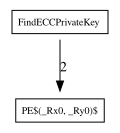

#### Counts totals:
 - `PE$(_Rx0, _Ry0)$`: 2

In [17]:
from qualtran.resource_counting.generalizers import ignore_split_join
ecc_g, ecc_sigma = ecc.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(ecc_g)
show_counts_sigma(ecc_sigma)

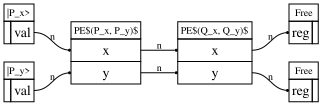

In [19]:
show_bloq(ecc.decompose_bloq())

### ECPhaseEstimateR

In [20]:
from qualtran.bloqs.cryptography.ecc import ECPhaseEstimateR

In [21]:
n, p = sympy.symbols("n p")
Rx, Ry = sympy.symbols("R_x R_y")
ec_pe = ECPhaseEstimateR(n=n, point=ECPoint(Rx, Ry, mod=p))

In [22]:
n = 3
Rx, Ry = sympy.symbols("R_x R_y")
ec_pe_small = ECPhaseEstimateR(n=n, point=ECPoint(Rx, Ry, mod=p))

In [24]:
from qualtran.drawing import show_bloqs
show_bloqs([ec_pe, ec_pe_small],
           ["`ec_pe`", "`ec_pe_small`"]
          )

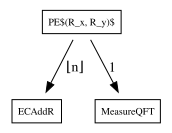

#### Counts totals:
 - `ECAddR`: $\displaystyle \left\lfloor{n}\right\rfloor$
 - `MeasureQFT`: 1

In [25]:
from qualtran.resource_counting.generalizers import ignore_split_join
ec_pe_g, ec_pe_sigma = ec_pe.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(ec_pe_g)
show_counts_sigma(ec_pe_sigma)

### ECAddR

In [32]:
from qualtran.bloqs.cryptography.ecc import ECAddR

n, p, Rx, Ry = sympy.symbols("n p R_x R_y")
ec_add_r = ECAddR(n=n, R=ECPoint(Rx, Ry, mod=p))

In [33]:
n = 5
P = ECPoint(15, 13, mod=17, curve_a=0)
ec_add_r_small = ECAddR(n=n, R=P)

In [34]:
from qualtran.drawing import show_bloqs
show_bloqs([ec_add_r, ec_add_r_small],
           ['`ec_add_r`', '`ec_add_r_small`'])

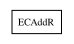

#### Counts totals:
 - `ECAddR`: 1

In [41]:
from qualtran.resource_counting.generalizers import ignore_split_join

ec_add_r_g, ec_add_r_sigma = ec_add_r.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(ec_add_r_g)
show_counts_sigma(ec_add_r_sigma)

In [42]:
for j in range(1, 20+1):
    bloq = ECAddR(n=5, R=j*P)
    ctrl, x, y = bloq.call_classically(ctrl=1, x=P.x, y=P.y)
    print(f'+[{j:2d}] P  ->  ({x:2d}, {y:2d})')

+[ 1] P  ->  ( 2, 10)
+[ 2] P  ->  ( 8,  3)
+[ 3] P  ->  (12,  1)
+[ 4] P  ->  ( 6,  6)
+[ 5] P  ->  ( 5,  8)
+[ 6] P  ->  (10, 15)
+[ 7] P  ->  ( 1, 12)
+[ 8] P  ->  ( 3,  0)
+[ 9] P  ->  ( 1,  5)
+[10] P  ->  (10,  2)
+[11] P  ->  ( 5,  9)
+[12] P  ->  ( 6, 11)
+[13] P  ->  (12, 16)
+[14] P  ->  ( 8, 14)
+[15] P  ->  ( 2,  7)
+[16] P  ->  (15,  4)
+[17] P  ->  ( 0,  0)
+[18] P  ->  (15, 13)
+[19] P  ->  ( 2, 10)
+[20] P  ->  ( 8,  3)


### ECWindowAddR

In [46]:
from qualtran.bloqs.cryptography.ecc import ECWindowAddR

n = 16
P = ECPoint(2, 2, mod=7, curve_a=3)
ec_window_add_r_small = ECWindowAddR(n=n, R=P, add_window_size=4)

In [47]:
from qualtran.drawing import show_bloqs
show_bloqs([ec_window_add_r_small],
           ['`ec_window_add_r_small`'])

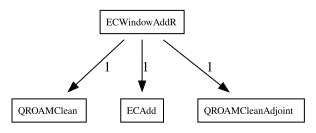

#### Counts totals:
 - `ECAdd`: 1
 - `QROAMCleanAdjoint`: 1
 - `QROAMClean`: 1

In [48]:
from qualtran.resource_counting.generalizers import ignore_split_join
ec_window_add_r_small_g, ec_window_add_r_small_sigma = ec_window_add_r_small.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(ec_window_add_r_small_g)
show_counts_sigma(ec_window_add_r_small_sigma)